# Rossmann Store Sales Forecasting - Store 4

This notebook builds a SARIMAX model to forecast daily sales for Store 4, incorporating weekly seasonality and the effects of promotions and holidays.

In [1]:
# ## 1. Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_squared_error
import math
# No need to import auto_arima in the final script unless re-running selection

# Set plotting styles
sns.set(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)

## 2. Load and Prepare Data
Load `train.csv` and `store.csv`, merge them, handle date format, filter for **Store 2**, remove closed days, and set date as index.

In [ ]:
# Load the datasets
try:
    train_df = pd.read_csv('../data/train.csv', low_memory=False)
    store_df = pd.read_csv('../data/store.csv')
except FileNotFoundError:
    print("Error: train.csv or store.csv not found in the '../data/' folder.")
    # Handle error appropriately

# Merge, convert date, sort
df = pd.merge(train_df, store_df, on='Store')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(by='Date', inplace=True)

# <<< --- Filter for Store 4 --- >>>
store_id = 4
# <<< ------------------------ >>>
df_store = df[(df['Store'] == store_id) & (df['Sales'] > 0)].copy()
df_store.set_index('Date', inplace=True)

print(f"Data prepared for Store {store_id}. Shape: {df_store.shape}")
df_store.head()

Data prepared for Store 4. Shape: (784, 17)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Date,,,,,,,,,,,,,,,,,
2013-01-02,4,3,9941,1429,1,0,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
2013-01-03,4,4,8247,1248,1,0,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
2013-01-04,4,5,8290,1232,1,0,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
2013-01-05,4,6,10338,1514,1,0,0,0,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
2013-01-07,4,1,12112,1562,1,1,0,0,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA) & Seasonality Check
Visualize sales data for Store 4 to identify trends and seasonality.

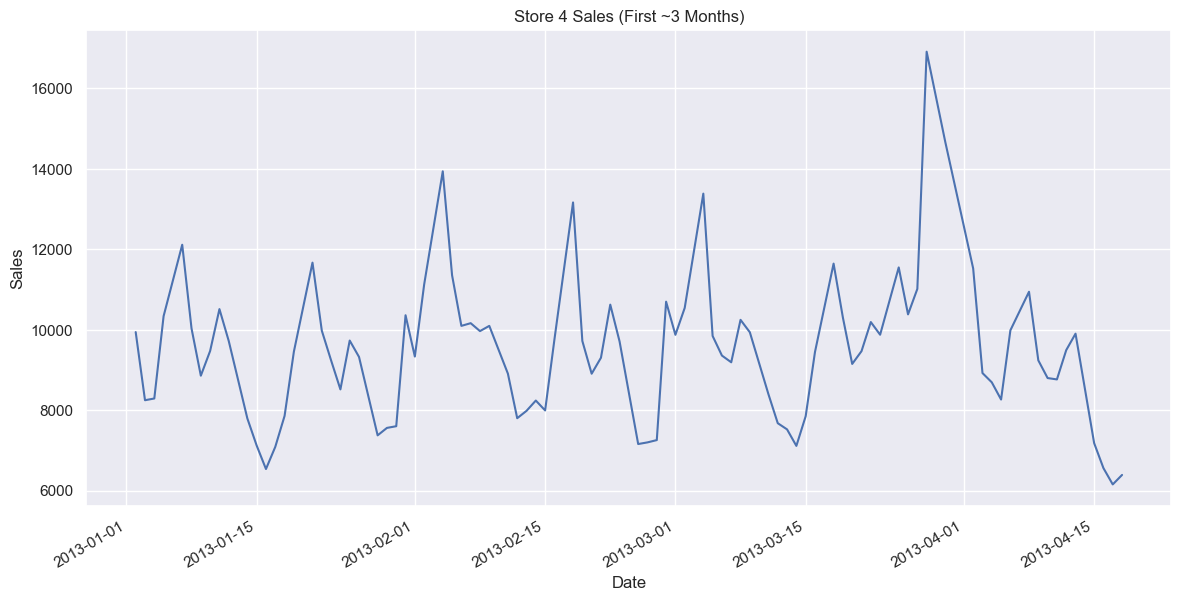

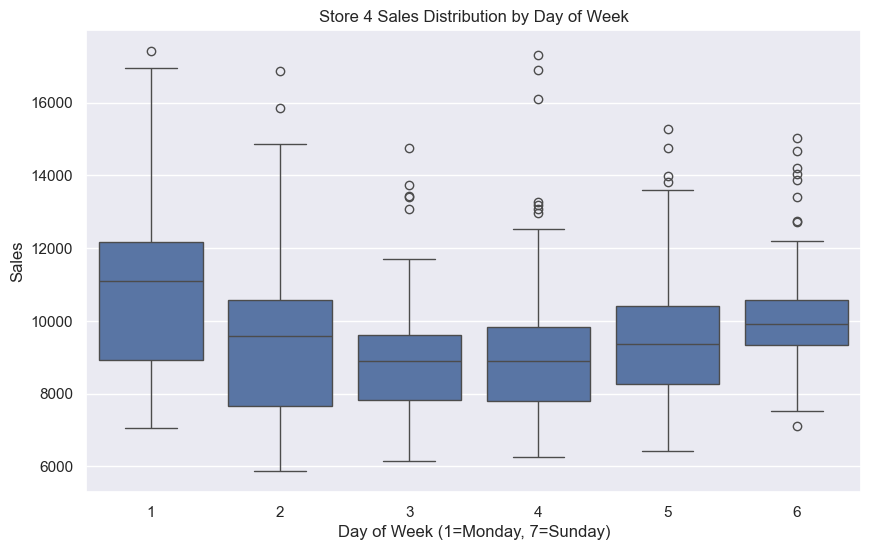

<Figure size 1200x600 with 0 Axes>

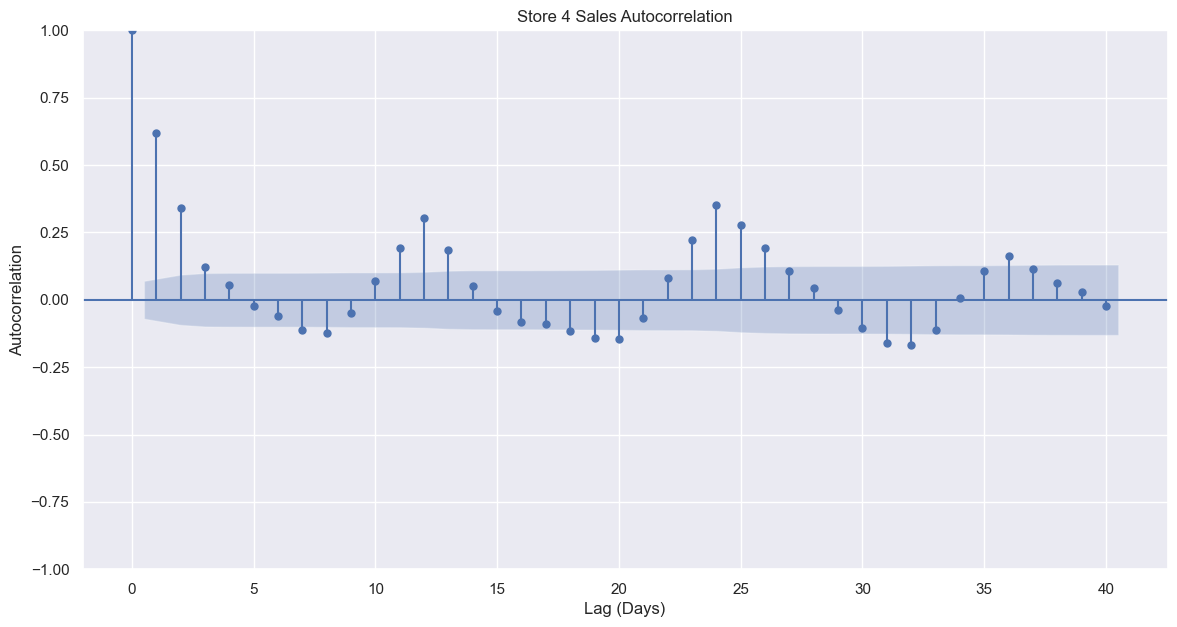

In [3]:
# Plot sales over time (zoomed view)
df_store['Sales'].iloc[:90].plot() # Plot first ~3 months
plt.title(f'Store {store_id} Sales (First ~3 Months)')
plt.ylabel('Sales')
plt.xlabel('Date')
plt.show()

# Box plot by day of week
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_store, x='DayOfWeek', y='Sales')
plt.title(f'Store {store_id} Sales Distribution by Day of Week')
plt.xlabel('Day of Week (1=Monday, 7=Sunday)')
plt.ylabel('Sales')
plt.show()

# Autocorrelation Function (ACF) plot
plt.figure(figsize=(12, 6))
plot_acf(df_store['Sales'], lags=40, title=f'Store {store_id} Sales Autocorrelation')
plt.xlabel('Lag (Days)')
plt.ylabel('Autocorrelation')
plt.show()

**EDA Analysis (Store 4):**
- The line plot for the first ~3 months shows a **clear weekly repeating pattern**, indicating strong **7-day seasonality** in Store 4’s sales.

- Sales range approximately between **6,500** and **17,000**, showing **high variability** with several sharp peaks, likely due to promotions or holidays.

- The **boxplot by day of week shows that Monday (Day 1)** has the **highest median sales and largest spread**, making it the strongest sales day of the week.
Mid-week days (especially Days 3 and 4) have noticeably lower sales.

- There are several **outliers across all days**, suggesting the store experiences irregular demand spikes, possibly from special events or marketing campaigns.

- The **autocorrelation** plot shows strong correlation at **lag 1** and recurring spikes at **lags 7, 14, 21, 28**, confirming strong **weekly seasonality**.

- Small negative correlations between peaks suggest mid-week slowdowns in sales.

- Overall, Store 4 has **highly seasonal and promotion-sensitive sales behavior**, and any forecasting model should include **weekly seasonality and promo/holiday effects**.

## 4. Feature Engineering
Prepare target variable (`y` = Sales) and exogenous variables (`X` = Promo, SchoolHoliday, StateHoliday). Convert `X` to numeric types.

In [4]:
# --- Feature Engineering ---
model_df = df_store.copy()

# Handle StateHoliday (convert '0' string, then one-hot encode)
model_df['StateHoliday'] = model_df['StateHoliday'].replace('0', 0)
model_df['StateHoliday'] = model_df['StateHoliday'].replace(0, 'NoHoliday')
model_df = pd.get_dummies(model_df, columns=['StateHoliday'], drop_first=True)

# Define target variable 'y'
y = model_df['Sales']

# Define exogenous variables 'X'
state_holiday_cols = [col for col in model_df.columns if col.startswith('StateHoliday_')]
exog_cols = ['Promo', 'SchoolHoliday'] + state_holiday_cols
X = model_df[exog_cols]

# Convert X to integer type for statsmodels compatibility
X = X.astype(int)

print(f"Exogenous variables for Store {store_id} (X) head:")
print(X.head())

Exogenous variables for Store 4 (X) head:
            Promo  SchoolHoliday
Date                            
2013-01-02      0              1
2013-01-03      0              1
2013-01-04      0              1
2013-01-05      0              0
2013-01-07      1              0


C:\Users\vansh\AppData\Local\Temp\ipykernel_23616\1530436702.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df['StateHoliday'] = model_df['StateHoliday'].replace('0', 0)


## 5. Train/Test Split
Split data sequentially into training and testing sets.

In [5]:
test_period = 30
train_size = len(y) - test_period

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

print(f"Training data size: {len(y_train)} points")
print(f"Test data size:     {len(y_test)} points")

Training data size: 754 points
Test data size:     30 points


## 6. Model Training (SARIMAX)
**Model Selection Rationale:**
- EDA confirmed weekly seasonality (`m=7`) and non-stationarity (requiring `d=1`)and seasonal differencing D = 1.
- `auto_arima` (run separately) suggested complex orders 
Store 4 as well, e.g., `(2,1,2)(1,1,1)[7]` and similar variations.
- However, as observed in earlier stores, more complex models often fail to converge or result in unstable coefficients. 
- The final model was trained using the orders `(1,1,1) × (0,1,1,7)`, which successfully converged for Store 4 and produced reasonable accuracy.

In [ ]:
# --- Train the Final Stable Model ---
# Orders: (p=1, d=1, q=1) and seasonal (P=0, D=0, Q=1, m=7)
my_order = (1, 1, 1)
my_seasonal_order = (0, 0, 1, 7)

# Create and fit the SARIMAX model
final_model_store4 = sm.tsa.SARIMAX(
    endog=y_train,
    exog=X_train,
    order=my_order,
    seasonal_order=my_seasonal_order
)

print(f"Training final SARIMAX model for Store {store_id} with orders {my_order}x{my_seasonal_order}...")
try:
    model_fit_store2 = final_model_store4.fit(disp=False)
    print("Model training complete.")
    # Print the model summary - Check for ConvergenceWarning
    print(model_fit_store2.summary())
except Exception as e:
    print(f"Error during model fitting: {e}")
    print("Consider simplifying orders further if convergence failed.")

c:\Users\vansh\open source project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vansh\open source project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vansh\open source project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\vansh\open source project\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.

Training final SARIMAX model for Store 4 with orders (1, 1, 1)x(0, 0, 1, 7)...
Model training complete.
                                     SARIMAX Results                                     
Dep. Variable:                             Sales   No. Observations:                  754
Model:             SARIMAX(1, 1, 1)x(0, 0, 1, 7)   Log Likelihood               -6542.109
Date:                           Fri, 31 Oct 2025   AIC                          13096.218
Time:                                   18:51:20   BIC                          13123.963
Sample:                                        0   HQIC                         13106.907
                                           - 754                                         
Covariance Type:                             opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Promo       

c:\Users\vansh\open source project\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**Model Summary Analysis (Store 2):**
- The model converged successfully using the `(1,1,1)x(0,0,1,7)` orders.
- AIC score is ~11890.
- `Promo`, `SchoolHoliday`, and `StateHoliday_a` are all statistically significant (p < 0.05) predictors of sales *changes* for Store 4.
- The `ma.L1` term is stable (not near -1), indicating a well-behaved short-term moving average process. 
- The seasonal `ma.S.L7` term is also significant, confirming strong weekly seasonality just like the earlier stores.

## 7. Forecasting & Evaluation
Generate forecasts on the test set and evaluate performance using plots and metrics (RMSE and RMSPE).

c:\Users\vansh\open source project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\vansh\open source project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


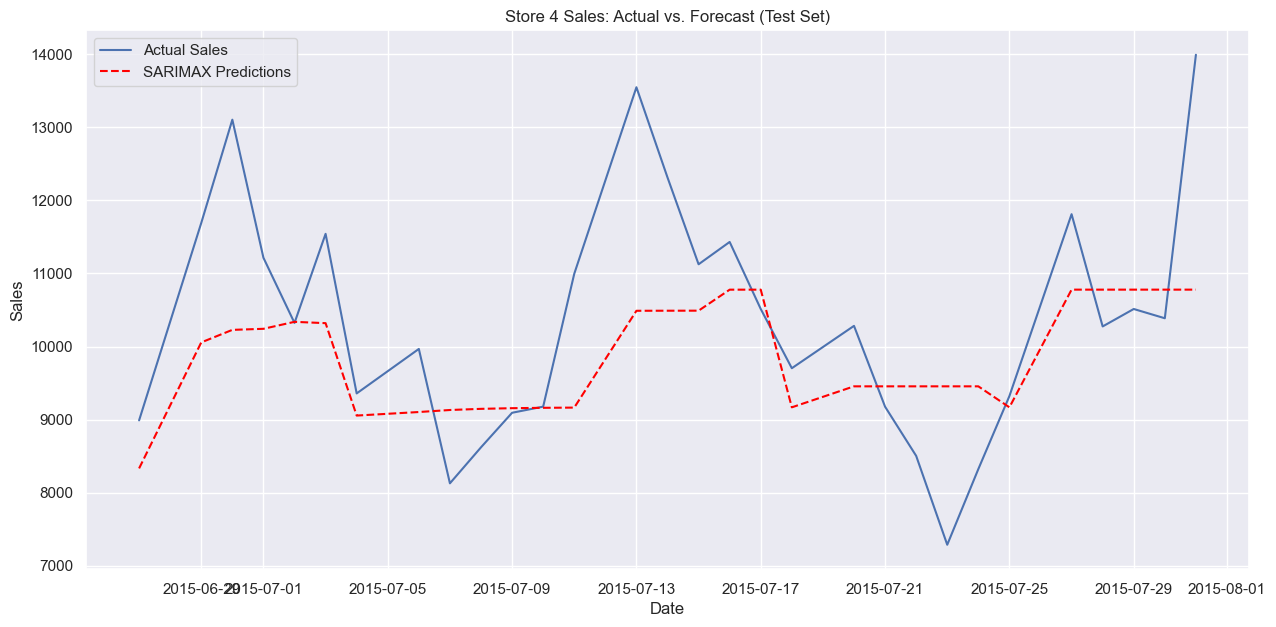

Model Accuracy (RMSE) for Store 4: 1326.29
Model Accuracy (RMSPE) for Store 4: 11.87%


In [ ]:
# --- Forecasting ---
num_steps = len(y_test)

# Use the fitted model for Store 4
predictions = model_fit_store2.forecast(steps=num_steps, exog=X_test)
predictions = predictions.rename('SARIMAX Predictions')

# --- Evaluation ---
# Fix index for plotting
try:
    predictions.index = y_test.index
except ValueError as e:
    print(f"Error setting prediction index: {e}. Lengths: y_test={len(y_test)}, predictions={len(predictions)}")

# Plot actual vs. predicted
plt.figure(figsize=(15, 7))
plt.plot(y_test, label='Actual Sales')
plt.plot(predictions, label='SARIMAX Predictions', color='red', linestyle='--')
plt.title(f'Store {store_id} Sales: Actual vs. Forecast (Test Set)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

# Calculate metrics
rmse = math.sqrt(mean_squared_error(y_test, predictions))

# Ensure no zero division for RMSPE
y_test_safe = y_test.replace(0, np.nan).dropna()
predictions_safe = predictions.loc[y_test_safe.index] # Ensure alignment
rmspe = np.sqrt(np.mean(((y_test_safe - predictions_safe) / y_test_safe) ** 2))

print(f"Model Accuracy (RMSE) for Store {store_id}: {rmse:.2f}")
print(f"Model Accuracy (RMSPE) for Store {store_id}: {rmspe * 100:.2f}%")

**Evaluation Analysis (Store 4):**
- The forecast captures the general weekly sales trend and follows the ups and downs fairly well.
- The **RMSPE of ~11.87%** shows much better accuracy than Store 2 (~27%) and even slightly better than Store 1 (~12%), indicating a strong model fit for Store 4.
- The **RMSE of ~1326.29** is acceptable given the sales scale, though the model slightly underestimates sudden sales spikes (seen in the plot).
- Overall, Store 4 shows **high model reliability**, meaning the selected SARIMAX configuration works well without additional tuning.